<a href="https://colab.research.google.com/github/mariammoatazmokhtar-crypto/MARIE_Calculator/blob/main/Garbage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving 4- GarBaGe.rar to 4- GarBaGe.rar
Buffered data was truncated after reaching the output size limit.

In [2]:
!apt-get install unrar -q
!unrar x "4- GarBaGe.rar" "/content/"

Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from 4- GarBaGe.rar

Creating    /content/4- GarBaGe                                       OK
Creating    /content/4- GarBaGe/test                                  OK
Extracting  /content/4- GarBaGe/test/predictions.csv                       0%  OK 
Creating    /content/4- GarBaGe/test/test_images                      OK
Extracting  /content/4- GarBaGe/test/test_images/img_1.jpg                 0%  OK 
Extracting  /content/4- GarBaGe/test/test_images/img_10.jpg                0%  OK 
Extracting  /content/4- GarBaGe/test/test_images/img_100.jpg               0%  OK 
Extracting  /content/4- GarBaGe/test/test_images/img_101.jpg               0%  OK 
Extractin

Found 1621 images belonging to 6 classes.
Found 403 images belonging to 6 classes.
✅ Number of classes: 6
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Starting Training...
Epoch 1/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 76s 438ms/step - accuracy: 0.3751 - loss: 1.6245 - val_accuracy: 0.5285 - val_loss: 1.2035
Epoch 2/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.5774 - loss: 1.1434 - val_accuracy: 0.5732 - val_loss: 1.1003
Epoch 3/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 35s 255ms/step - accuracy: 0.6268 - loss: 1.0001 - val_accuracy: 0.6055 - val_loss: 0.9803
Epoch 4/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.6453 - loss: 0.9449 - val_accuracy: 0.6328 - val_loss: 0.9440
Epoch 5/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 224ms/step - accuracy: 0.6774 - loss: 0.8840 - val_accuracy: 0.6328 - val_loss: 0.9267
Epoch 6/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 214ms/step - accuracy: 0.6841 - loss: 0.8520 - val_accuracy: 0.6253 - val_loss: 0.9413
Epoch 7/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - accuracy: 0.7107 - loss: 0.7708 - val_accuracy: 0.6303 - val_loss: 0.9307
Epoch 8/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 31s 225ms/step - ac

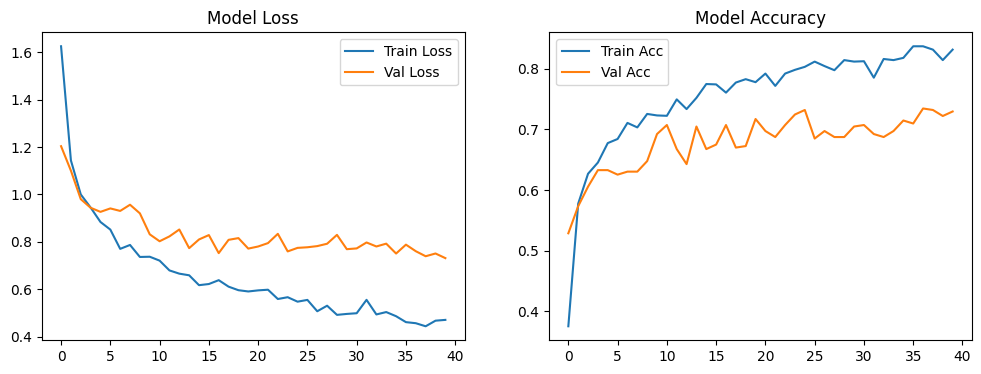

📸 Test images found: 0
✅ File saved to /content/predictions.csv


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models



# ========== 2. المسارات ==========
DATA_DIR = "/content/4- GarBaGe/train"
TEST_IMAGES_DIR = "/content/4- GarBaGe/test"
OUTPUT_CSV_PATH = "/content/predictions.csv"

# ========== 3. الثوابت ==========
SEED = 25
IMG_SIZE = (224, 224)
BATCH_SIZE = 12
EPOCHS = 40
LR = 0.0001

np.random.seed(SEED)
tf.random.set_seed(SEED)

def preprocess_edges(img):
    # تحويل لـ grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # كشف الحواف باستخدام Canny
    edges = cv2.Canny(gray, 50, 150)

    # تحويل الحواف لـ 3 قنوات (عشان تدخل للنموذج)
    edges_3channel = np.stack([edges, edges, edges], axis=2)

    # دمج الصورة الأصلية مع الحواف (ratio 70% original, 30% edges)
    combined = img * 0.3 + edges_3channel * 0.7
    return combined.astype(np.uint8)
# ========== 4. دالة لتحويل أي صورة لـ 3 قنوات ==========
def ensure_rgb(img):
    if img.shape[-1] == 4:
        img = img[..., :3]
    return img

# ========== 5. Data Generator ==========
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.4,
    brightness_range=[0.3, 1.7],
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)
train_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    color_mode='rgb'
)

val_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    color_mode='rgb'
)

num_classes = len(train_ds.class_indices)
print(f"✅ Number of classes: {num_classes}")

# ========== 6. النموذج ==========
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
opt = tf.keras.optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ========== 7. Early Stopping ==========
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# ========== 8. التدريب ==========
print("\n🚀 Starting Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

# ========== 9. رسم النتائج ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Model Accuracy')
ax2.legend()
plt.show()

# ========== 10. التنبؤ على صور test ==========
test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"📸 Test images found: {len(test_images)}")

predicted_labels = []
for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)
    predicted_labels.append(np.argmax(pred))

submission_df = pd.DataFrame({'id': test_images, 'label': predicted_labels})
submission_df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✅ File saved to {OUTPUT_CSV_PATH}")